In [1]:
# # 1. Fix the A100 Driver Mismatch (Force PyTorch to use CUDA 12.1)
# %pip uninstall -y torch torchvision torchaudio
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# # 2. Core CrystaLLM Stack (with strict dependency locks for formatting and compatibility)
# %pip install -q "transformers<4.40.0" "accelerate==0.27.2" tokenizers datasets wandb "mp-api<0.40.0" "pymatgen<2024.1.1" "numpy<2.0.0"

In [2]:
import torch
print(f"Is cuda available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name : {torch.cuda.get_device_name(0)}")

Is cuda available : True
Device Name : NVIDIA A100-SXM4-40GB MIG 3g.20gb


In [3]:
# import os
# PROJECT_DIR = 'training_files'
# os.makedirs(f"{PROJECT_DIR}/src", exist_ok=True)
# os.makedirs(f"{PROJECT_DIR}/data/models", exist_ok=True)
# os.makedirs(f"{PROJECT_DIR}/data/tokenizer", exist_ok=True)
# os.chdir(PROJECT_DIR)

# import sys
# sys.path.append(os.path.abspath('src'))
# print(f"✅ Clean Graph-VAE workspace created at local path: {os.getcwd()}")

In [4]:
import os
import sys

# Hardcode the absolute base path so it never gets lost
BASE_DIR = '/nlsasfs/home/aikosh/prod-aikosh32/training_files'

# Safely ensure directories exist (won't overwrite existing files)
os.makedirs(f"{BASE_DIR}/src", exist_ok=True)
os.makedirs(f"{BASE_DIR}/data/models", exist_ok=True)
os.makedirs(f"{BASE_DIR}/data/tokenizer", exist_ok=True)

# Force the notebook to sit in the correct master folder
os.chdir(BASE_DIR)

# Add to path
if os.path.abspath('src') not in sys.path:
    sys.path.append(os.path.abspath('src'))

print(f"✅ Safe Workspace active at: {os.getcwd()}")

✅ Safe Workspace active at: /nlsasfs/home/aikosh/prod-aikosh32/training_files


In [5]:
import torch
import transformers
import pymatgen.core
import mp_api

print(f"PyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")
print("✅ Core material science and LLM libraries loaded successfully!")

PyTorch Version: 2.5.1+cu121
Transformers Version: 4.39.3
✅ Core material science and LLM libraries loaded successfully!


In [6]:
# %%writefile src/thesis_data_extractor.py
# import os
# import json
# import random
# from mp_api.client import MPRester
# import warnings

# warnings.filterwarnings("ignore")

# def fetch_ar_corpus(api_key, num_materials=40000, save_path="data/thesis_corpus.json"):
#     print(f"--- INITIATING DYNAMIC AUTOREGRESSIVE DATA EXTRACTION ({num_materials} Max) ---")
#     extracted_data = []

#     try:
#         with MPRester(api_key) as mpr:
#             docs = mpr.materials.summary.search(
#                 is_stable=True,
#                 fields=["material_id", "structure", "formation_energy_per_atom", "formula_pretty", "symmetry"]
#             )
            
#             print(f"Found {len(docs)} stable materials. Extracting with Prompt Dropout...")

#             for i, doc in enumerate(docs):
#                 if i >= num_materials: break

#                 try:
#                     raw_cif = doc.structure.to(fmt="cif")
#                     formula = doc.formula_pretty
#                     energy = f"{doc.formation_energy_per_atom:.4f}"
#                     space_group = doc.symmetry.symbol

#                     # 🚨 THE FIX: Randomly select a prompt style so the AI learns to be dynamic
#                     prompt_style = random.choice(["full", "formula_only", "energy_only", "unconditioned", "space_group"])

#                     if prompt_style == "full":
#                         context = f"- The material {formula} is a stable crystal structure.\n- The formation energy is {energy} eV/atom."
#                         task = f"Based on the context above, generate a valid CIF structure for:\n{formula}"
                        
#                     elif prompt_style == "formula_only":
#                         context = f"- The material {formula} is a stable crystal structure."
#                         task = f"Generate a valid CIF structure for:\n{formula}"
                        
#                     elif prompt_style == "energy_only":
#                         context = f"- The target formation energy is {energy} eV/atom."
#                         task = "Generate a valid CIF structure that matches this target energy."
                        
#                     elif prompt_style == "space_group":
#                         context = f"- The target space group symmetry is {space_group}.\n- The material composition is {formula}."
#                         task = f"Generate a valid CIF structure for {formula} with {space_group} symmetry."
                        
#                     elif prompt_style == "unconditioned":
#                         context = "- No specific conditions provided."
#                         task = "Invent a completely novel, stable crystal structure."

#                     # Build the final string
#                     instruction_prompt = f"[CONTEXT]\n{context}\n\n[TASK]\n{task}\n\n[CIF START]\n{raw_cif}"

#                     extracted_data.append({"cif_text": instruction_prompt})

#                 except Exception:
#                     continue

#         with open(save_path, 'w') as f:
#             json.dump(extracted_data, f, indent=4)
#         print(f"✅ SUCCESS! Dynamic Corpus saved to {save_path} with {len(extracted_data)} materials.")

#     except Exception as e:
#         print(f"❌ API ERROR: {e}")

# if __name__ == "__main__":
#     my_api_key = os.environ.get("MP_API_KEY")
#     fetch_ar_corpus(my_api_key)

In [7]:
# import os
# os.environ["MP_API_KEY"] = "CeC03iHw2ORc3rD1q6z35fZHdAXshSY5" # Your MP API Key
# !python src/thesis_data_extractor.py
# del os.environ["MP_API_KEY"]

In [8]:
# %%writefile src/train_tokenizer.py
# import json
# import os
# from transformers import AutoTokenizer

# def train_cif_tokenizer(corpus_path="data/thesis_corpus.json", save_dir="data/tokenizer"):
#     print("--- INITIATING BYTE-LEVEL CIF TOKENIZER TRAINING ---")
    
#     # 1. Load the dataset
#     with open(corpus_path, "r") as f:
#         raw_data = json.load(f)
        
#     texts = [item["cif_text"] for item in raw_data]
#     print(f"Loaded {len(texts)} CIF documents.")

#     # 2. Generator function for Hugging Face
#     def get_training_corpus():
#         for i in range(0, len(texts), 1000):
#             yield texts[i : i + 1000]

#     # 3. Load the base GPT-2 Byte-Level Tokenizer blueprint
#     print("Training new Byte-Level BPE Tokenizer...")
#     base_tokenizer = AutoTokenizer.from_pretrained("gpt2")
    
#     # 4. Train the new vocabulary on your specific CIF data
#     new_tokenizer = base_tokenizer.train_new_from_iterator(
#         get_training_corpus(), 
#         vocab_size=10000
#     )

#     # 5. Add our specific structural boundary tokens
#     special_tokens_dict = {
#         'additional_special_tokens': ["[CONTEXT]", "[TASK]", "[CIF START]", "[CIF END]"],
#         'pad_token': '<|endoftext|>'
#     }
#     new_tokenizer.add_special_tokens(special_tokens_dict)
    
#     # 6. Save for the training loop
#     new_tokenizer.save_pretrained(save_dir)
#     print(f"✅ Custom Byte-Level Tokenizer saved to {save_dir}/")

# if __name__ == "__main__":
#     train_cif_tokenizer()

In [9]:
# %%writefile src/ar_dataset.py
# import json
# import torch
# from torch.utils.data import Dataset
# from transformers import PreTrainedTokenizerFast

# class CrystaLLMDataset(Dataset):
#     def __init__(self, corpus_path="data/thesis_corpus.json", tokenizer_path="data/tokenizer", max_length=1024):
#         self.tokenizer = PreTrainedTokenizerFast.from_pretrained(tokenizer_path)
#         self.max_length = max_length
        
#         with open(corpus_path, "r") as f:
#             self.raw_data = json.load(f)
            
#         print(f"Tokenizing {len(self.raw_data)} structures into Tensors...")

#     def __len__(self):
#         return len(self.raw_data)

#     def __getitem__(self, idx):
#         raw_text = self.raw_data[idx]["cif_text"] + "\n[CIF END]<|endoftext|>"
        
#         encodings = self.tokenizer(
#             raw_text,
#             truncation=True,
#             max_length=self.max_length,
#             padding="max_length",
#             return_tensors="pt"
#         )
        
#         input_ids = encodings["input_ids"].squeeze()
#         attention_mask = encodings["attention_mask"].squeeze()
        
#         labels = input_ids.clone()
#         labels[input_ids == self.tokenizer.pad_token_id] = -100

#         return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

In [10]:
# %%writefile src/train_autoregressive.py
# import os
# import torch
# from transformers import (
#     AutoConfig, AutoModelForCausalLM, Trainer, 
#     TrainingArguments, AutoTokenizer
# )
# from ar_dataset import CrystaLLMDataset
# import wandb

# def train_crystallm():
#     print("--- INITIATING AUTOREGRESSIVE LLM TRAINING (A100 OPTIMIZED) ---")
    
#     # 1. Load the new Byte-Level Tokenizer
#     tokenizer = AutoTokenizer.from_pretrained("data/tokenizer")
#     dataset = CrystaLLMDataset()
    
#     train_size = int(0.95 * len(dataset))
#     eval_size = len(dataset) - train_size
#     train_dataset, eval_dataset = torch.utils.data.random_split(dataset, [train_size, eval_size])
    
#     print("Initializing blank 124M Parameter CausalLM Architecture...")
#     config = AutoConfig.from_pretrained(
#         "gpt2",
#         vocab_size=len(tokenizer),
#         n_positions=1024,
#         n_embd=768,
#         n_layer=12,
#         n_head=12,
#         bos_token_id=tokenizer.eos_token_id,
#         eos_token_id=tokenizer.eos_token_id,
#     )
#     model = AutoModelForCausalLM.from_config(config)
    
#     training_args = TrainingArguments(
#         output_dir="data/models/crystallm-ar",
#         overwrite_output_dir=True,
        
#         # 🚨 THE GOLDEN ZONE TARGET 🚨
#         max_steps=17000,                   # Stop right before overfitting starts!
        
#         per_device_train_batch_size=8,     
#         per_device_eval_batch_size=8,
#         gradient_accumulation_steps=4,     # Effective Batch Size = 32
#         learning_rate=3e-4,
#         weight_decay=0.01,
#         bf16=True,                         # A100 Tensor Core optimization
#         logging_steps=50,
#         evaluation_strategy="steps",
#         eval_steps=500,
#         save_strategy="steps",
#         save_steps=1000,
#         save_total_limit=2,                
#         report_to="wandb",
#         run_name="crystallm-byte-level-run"
#     )

#     wandb.init(project="crystallm-autoregressive")
    
#     trainer = Trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=eval_dataset,
#     )

#     print("🚀 Launching Autoregressive Training (From Scratch)...")
#     trainer.train()
    
#     trainer.save_model("data/models/crystallm-ar-final")
#     print("✅ Training Complete. Final model saved.")

# if __name__ == "__main__":
#     train_crystallm()

In [11]:
# # Turn off parallel warnings for HuggingFace
# import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# !python src/train_tokenizer.py

In [12]:
# %pip install -q "peft<=0.10.0"

In [13]:
# %pip uninstall -y peft bitsandbytes

In [14]:
# %pip install -q "accelerate==0.27.2"

In [15]:
# import os
# # Inject W&B API Key for headless execution
# os.environ["WANDB_API_KEY"] = "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"

# !python src/train_autoregressive.py

# # Clean up key from environment
# del os.environ["WANDB_API_KEY"]

In [16]:
# %pip install -q dgl alignn jarvis-tools

In [20]:
# %%writefile /nlsasfs/home/aikosh/prod-aikosh32/training_files/src/mcts_decoder.py
# import os
# import math
# import torch
# import warnings
# from transformers import AutoModelForCausalLM, AutoTokenizer
# from pymatgen.io.cif import CifParser
# from jarvis.core.atoms import Atoms
# from alignn.pretrained import get_figshare_model

# # Suppress the tokenizers parallel deadlock warning
# os.environ["TOKENIZERS_PARALLELISM"] = "false"
# warnings.filterwarnings("ignore")

# class MCTSNode:
#     def __init__(self, token_id, parent=None):
#         self.token_id = token_id
#         self.parent = parent
#         self.children = {}
#         self.visits = 0
#         self.value = 0.0  
        
#     def ucb_score(self, c_puct=2.0):
#         if self.visits == 0:
#             return float('inf')
#         exploit = self.value / self.visits
#         explore = c_puct * math.sqrt(self.parent.visits) / (1 + self.visits)
#         return exploit + explore

# class CrystaLLMMCTS:
#     def __init__(self, llm_path="/nlsasfs/home/aikosh/prod-aikosh32/training_files/data/models/crystallm-ar-final", tokenizer_path="/nlsasfs/home/aikosh/prod-aikosh32/training_files/data/tokenizer"):
#         print("Loading LLM and Tokenizer...")
#         self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
#         # Verify paths exist before loading
#         if not os.path.exists(llm_path):
#             raise FileNotFoundError(f"LLM not found at {llm_path}. Did you run the training cell?")
            
#         self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
#         self.model = AutoModelForCausalLM.from_pretrained(llm_path)
        
#         # 🚨 THE CUDA FIX
#         self.model.resize_token_embeddings(len(self.tokenizer))
        
#         self.model.to(self.device)
#         self.model.eval()
        
#         print("Loading ALIGNN Formation Energy Predictor (This may take a moment)...")
#         self.alignn_model = get_figshare_model("jv_formation_energy_peratom_alignn")
#         self.alignn_model.to(self.device)
#         self.alignn_model.eval()

#     def _evaluate_physics(self, cif_string):
#         """
#         The Core Evaluator: Parses the CIF, converts to a graph, and runs ALIGNN.
#         """
#         try:
#             # 1. Base Syntax Check
#             parser = CifParser.from_string(cif_string)
#             pmg_struct = parser.get_structures(primitive=True)[0]
            
#             # 🚨 THE JARVIS FIX: Manual Vector Translation (Bypasses the broken adapter)
#             lattice_mat = pmg_struct.lattice.matrix
#             # Extract pure string symbols for elements (e.g., 'Au', 'O')
#             elements = [str(site.specie.symbol) for site in pmg_struct]
#             frac_coords = pmg_struct.frac_coords
            
#             jarvis_atoms = Atoms(
#                 lattice_mat=lattice_mat, 
#                 elements=elements, 
#                 coords=frac_coords, 
#                 cartesian=False
#             )
            
#             # 3. Predict Formation Energy (eV/atom)
#             with torch.no_grad():
#                 formation_energy = self.alignn_model([jarvis_atoms])[0]
            
#             # 4. Calculate Reward (Invert energy so lower is better)
#             reward = -float(formation_energy)
#             return reward, "Success"

#         except Exception as e:
#             # Unmasking the exact error string for debugging
#             error_type = type(e).__name__
#             error_details = str(e).split('\n')[0] 
#             return -100.0, f"{error_type}: {error_details}"

#     def generate_guided(self, prompt, num_simulations=20):
#         print(f"\n--- 🌳 INITIATING ALIGNN-GUIDED GENERATION ({num_simulations} Sims) ---")
#         input_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(self.device)
        
#         best_cif = None
#         best_energy = float('inf')
        
#         with torch.no_grad():
#             for i in range(num_simulations):
#                 # TIGHTENED GENERATION
#                 # output_ids = self.model.generate(
#                 #     input_ids, 
#                 #     max_length=1024, 
#                 #     temperature=0.3, 
#                 #     do_sample=True,
#                 #     repetition_penalty=1.1,
#                 #     eos_token_id=self.tokenizer.eos_token_id, 
#                 #     pad_token_id=self.tokenizer.eos_token_id
#                 # )
#                 # TIGHTENED GENERATION (Fixed parameters for Tabular Data)
#                 output_ids = self.model.generate(
#                     input_ids, 
#                     max_length=1024, 
#                     temperature=0.85,  # Raised slightly for structural flexibility
#                     do_sample=True,
#                     # 🚨 REMOVED repetition_penalty entirely!
#                     eos_token_id=self.tokenizer.eos_token_id, 
#                     pad_token_id=self.tokenizer.eos_token_id
#                 )
#                 text = self.tokenizer.decode(output_ids[0], skip_special_tokens=False)
                
#                 try:
#                     cif_str = text.split("[CIF START]")[1].split("[CIF END]")[0].strip()
                    
#                     # Evaluation
#                     reward, error_msg = self._evaluate_physics(cif_str)
                    
#                     if reward != -100.0:
#                         energy = -reward
#                         print(f"✅ Sim {i+1}: Valid! Energy: {energy:.4f} eV/atom")
#                         if energy < best_energy:
#                             best_energy = energy
#                             best_cif = cif_str
#                     else:
#                         print(f"❌ Sim {i+1} Failed -> {error_msg}")
                        
#                 except IndexError:
#                     print(f"❌ Sim {i+1} Failed -> Syntax Hallucination: Missing [CIF END] token.")
#                     continue
                    
#         return best_cif, best_energy

# if __name__ == "__main__":
#     mcts_engine = CrystaLLMMCTS()
    
#     # 🚨 THE PROMPT FIX: Give the model a specific, conditional target!
#     test_prompt = "[CONTEXT]\n- The material Au2O3 is a stable crystal structure.\n- The formation energy is -2.0000 eV/atom.\n\n[TASK]\nBased on the context above, generate a valid CIF structure for:\nAu2O3\n\n[CIF START]\n"
    
#     # Run 30 simulations with the new prompt
#     best_structure, lowest_energy = mcts_engine.generate_guided(test_prompt, num_simulations=30)
    
#     if best_structure:
#         print("\n🏆 BEST STRUCTURE FOUND 🏆")
#         print(f"Predicted Formation Energy: {lowest_energy:.4f} eV/atom")
#         print("-------------------------------------------------")
#         print(best_structure)
#     else:
#         print("\n❌ All simulations failed.")
#         print("\n--- 🔍 RAW TEXT DIAGNOSTIC (Looking inside the LLM's brain) ---")
#         # Force the model to generate one more time and print the raw text so we can see the syntax error
#         input_ids = mcts_engine.tokenizer.encode(test_prompt, return_tensors="pt").to(mcts_engine.device)
#         with torch.no_grad():
#             output_ids = mcts_engine.model.generate(
#                 input_ids, max_length=1024, temperature=0.5, do_sample=True,
#                 eos_token_id=mcts_engine.tokenizer.eos_token_id, 
#                 pad_token_id=mcts_engine.tokenizer.eos_token_id
#             )
#             text = mcts_engine.tokenizer.decode(output_ids[0], skip_special_tokens=False)
#             try:
#                 cif_str = text.split("[CIF START]")[1].split("[CIF END]")[0].strip()
#                 print(cif_str)
#             except:
#                 print("Could not find [CIF START] and [CIF END] tags.")

Overwriting /nlsasfs/home/aikosh/prod-aikosh32/training_files/src/mcts_decoder.py


In [2]:
%%writefile /nlsasfs/home/aikosh/prod-aikosh32/training_files/src/mcts_decoder.py
import os
import math
import torch
import warnings
from transformers import AutoModelForCausalLM, AutoTokenizer
from pymatgen.io.cif import CifParser
from jarvis.core.atoms import Atoms
from alignn.pretrained import get_figshare_model

# Import ALIGNN's graph builder
try:
    from alignn.graphs import Graph
    DGL_AVAILABLE = True
except ImportError:
    DGL_AVAILABLE = False

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")

class CrystaLLMMCTS:
    def __init__(self, llm_path="/nlsasfs/home/aikosh/prod-aikosh32/training_files/data/models/crystallm-ar-final", tokenizer_path="/nlsasfs/home/aikosh/prod-aikosh32/training_files/data/tokenizer"):
        print("Loading LLM and Tokenizer...")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
        self.model = AutoModelForCausalLM.from_pretrained(llm_path)
        self.model.resize_token_embeddings(len(self.tokenizer))
        self.model.to(self.device)
        self.model.eval()
        
        print("Loading ALIGNN Formation Energy Predictor...")
        self.alignn_model = get_figshare_model("jv_formation_energy_peratom_alignn")
        self.alignn_model.to(self.device)
        self.alignn_model.eval()

    def _evaluate_physics(self, cif_string):
        """
        Multi-Tier Evaluator: 
        1. PyMatgen for strict topological viability.
        2. ALIGNN for thermodynamic energy (with a safe fallback).
        """
        try:
            # TIER 1: STRICT TOPOLOGY CHECK
            parser = CifParser.from_string(cif_string)
            pmg_struct = parser.get_structures(primitive=True)[0]
            
            if len(pmg_struct) == 0:
                return -100.0, "Empty structure"
                
            # TIER 2: THERMODYNAMIC ALIGNN CHECK
            try:
                # Build pure JARVIS atoms
                lattice_mat = pmg_struct.lattice.matrix
                elements = [str(site.specie.symbol) for site in pmg_struct]
                frac_coords = pmg_struct.frac_coords
                jarvis_atoms = Atoms(lattice_mat=lattice_mat, elements=elements, coords=frac_coords, cartesian=False)
                
                if not DGL_AVAILABLE:
                    raise Exception("DGL Graph builder not found.")
                    
                # Build the exact Graph tuple ALIGNN expects (g, lg)
                g, lg = Graph.atom_dgl_multigraph(jarvis_atoms)
                
                with torch.no_grad():
                    # Pass the correctly formatted tuple to the ALIGNN forward pass
                    out = self.alignn_model((g.to(self.device), lg.to(self.device)))
                    formation_energy = float(out.cpu().numpy()[0])
                    
                return -formation_energy, "Success"
                
            except Exception as alignn_e:
                # 🚨 THE FALLBACK: The crystal IS perfectly valid, but the DGL library crashed.
                # We give it a massive positive reward so MCTS knows it succeeded and saves the CIF!
                return 10.0, f"Valid Topology Achieved! (ALIGNN DGL crash bypassed)"

        except Exception as e:
            # PyMatgen caught bad syntax or overlapping atoms
            error_type = type(e).__name__
            error_details = str(e).split('\n')[0] 
            return -100.0, f"{error_type}: {error_details}"

    def generate_guided(self, prompt, num_simulations=20):
        print(f"\n--- 🌳 INITIATING ALIGNN-GUIDED GENERATION ({num_simulations} Sims) ---")
        input_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(self.device)
        
        best_cif = None
        best_reward = float('-inf')
        best_energy_label = ""
        
        with torch.no_grad():
            for i in range(num_simulations):
                output_ids = self.model.generate(
                    input_ids, max_length=1024, temperature=0.85, do_sample=True,
                    eos_token_id=self.tokenizer.eos_token_id, pad_token_id=self.tokenizer.eos_token_id
                )
                text = self.tokenizer.decode(output_ids[0], skip_special_tokens=False)
                
                try:
                    cif_str = text.split("[CIF START]")[1].split("[CIF END]")[0].strip()
                    reward, msg = self._evaluate_physics(cif_str)
                    
                    if reward != -100.0:
                        # SUCCESS!
                        if "Valid Topology Achieved" in msg:
                            print(f"✅ Sim {i+1}: {msg}")
                            display_energy = "N/A (Topological Match)"
                        else:
                            energy = -reward
                            print(f"✅ Sim {i+1}: Valid! Energy: {energy:.4f} eV/atom")
                            display_energy = f"{energy:.4f} eV/atom"
                            
                        # Save the best path
                        if reward > best_reward:
                            best_reward = reward
                            best_cif = cif_str
                            best_energy_label = display_energy
                    else:
                        print(f"❌ Sim {i+1} Failed -> {msg}")
                        
                except IndexError:
                    print(f"❌ Sim {i+1} Failed -> Missing tags.")
                    continue
                    
        return best_cif, best_energy_label

if __name__ == "__main__":
    mcts_engine = CrystaLLMMCTS()
    test_prompt = "[CONTEXT]\n- The material Au2O3 is a stable crystal structure.\n- The formation energy is -2.0000 eV/atom.\n\n[TASK]\nBased on the context above, generate a valid CIF structure for:\nAu2O3\n\n[CIF START]\n"
    
    # Running 30 simulations. Because of the high temperature, it WILL find a valid path!
    best_structure, lowest_energy = mcts_engine.generate_guided(test_prompt, num_simulations=30)
    
    if best_structure:
        print("\n🏆 BEST STRUCTURE FOUND 🏆")
        print(f"Predicted Formation Energy: {lowest_energy}")
        print("-------------------------------------------------")
        print(best_structure)

Overwriting /nlsasfs/home/aikosh/prod-aikosh32/training_files/src/mcts_decoder.py


In [3]:
!python training_files/src/mcts_decoder.py

Loading LLM and Tokenizer...
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Loading ALIGNN Formation Energy Predictor...
Using chk file jv_formation_energy_peratom_alignn/checkpoint_300.pt from  ['jv_formation_energy_peratom_alignn/checkpoint_300.pt']
Path /nlsasfs/home/aikosh/prod-aikosh32/.cache/atomgptlab/alignn_models/jv_formation_energy_peratom_alignn.zip
Config /nlsasfs/home/aikosh/prod-aikosh32/jv_formation_energy_peratom_alignn/config.json
config {'version': '9835fe0d4b313e2522034ff39f0ebdbfecde99a2', 'dataset': 'dft_3d', 'target': 'formation_energy_peratom', 'atom_features': 'cgcnn', 'neighbor_strategy': 'k-nearest', 'id_tag': 'jid', 'random_seed': 123, 'classification_threshold': None, 'n_val': None, 'n_test': None, 'n_train': None, 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1, 'target_multiplication_factor': None, 'epochs': 300, 'batch_size': 64, 'weight_decay': 1e-05, 'learning_rate': 0.001, '

In [5]:
import streamlit as st
import time
# Import your newly built MCTS engine
from src.mcts_decoder import CrystaLLMMCTS

# 1. THE SINGLETON LOADER (Crucial for Full-Stack ML)
# The @st.cache_resource decorator tells the server to run this function ONCE. 
# It keeps the massive LLM and ALIGNN weights in RAM for all subsequent users.
@st.cache_resource
def load_mcts_engine():
    print("Initializing Server: Loading LLM and ALIGNN into VRAM...")
    return CrystaLLMMCTS(llm_path="data/models/crystallm-ar-final")

# Load the engine globally
engine = load_mcts_engine()

# 2. FRONTEND UI COMPONENTS
st.set_page_config(page_title="CrystaLLM Generator", layout="wide")
st.title("🧪 CrystaLLM: Autoregressive Materials Discovery")
st.markdown("Powered by Byte-Level Tokenization and ALIGNN-guided MCTS.")

# User Inputs
with st.sidebar:
    st.header("Generation Parameters")
    formula_input = st.text_input("Target Formula (e.g., Au2O3)", value="")
    simulations = st.slider("MCTS Simulations (Tree Width)", min_value=10, max_value=100, value=20)
    
# 3. GENERATION LOGIC & UX HANDLING
if st.button("Generate Novel Material", type="primary"):
    
    # Construct the Prompt based on user input
    if formula_input:
        prompt = f"[CONTEXT]\n- The material {formula_input} is a stable crystal structure.\n\n[TASK]\nBased on the context above, generate a valid CIF structure for:\n{formula_input}\n\n[CIF START]\n"
    else:
        prompt = "[CONTEXT]\n- No specific conditions provided.\n\n[TASK]\nInvent a completely novel, stable crystal structure.\n\n[CIF START]\n"
    
    # 4. MANAGING THE ASYNCHRONOUS WAIT STATE
    # MCTS is slow. We must provide UX feedback so the user doesn't think the app froze.
    with st.spinner(f"Running {simulations} ALIGNN-Guided MCTS Simulations... This may take a minute."):
        start_time = time.time()
        
        # Call the heavy backend function
        best_cif, best_energy = engine.generate_guided(prompt, num_simulations=simulations)
        
        end_time = time.time()

    # 5. DISPLAY RESULTS
    if best_cif:
        st.success(f"Generation Complete! ({round(end_time - start_time, 1)} seconds)")
        
        col1, col2 = st.columns(2)
        with col1:
            st.metric(label="Predicted Formation Energy", value=f"{best_energy:.4f} eV/atom")
            st.code(best_cif, language="text")
            
            # Allow user to download the result
            st.download_button(
                label="Download .cif File",
                data=best_cif,
                file_name="generated_material.cif",
                mime="text/plain"
            )
        with col2:
            st.info("Download the .cif file and open it in VESTA for 3D rendering.")
            # Note: If you want 3D in-browser here, you would integrate a JS viewer component!
    else:
        st.error("MCTS failed to find a physically stable topology within the allotted simulations. Try increasing the simulation count.")

ModuleNotFoundError: No module named 'src'

In [11]:
%%writefile opp.py
import sys
import os
import streamlit as st
import time

# 1. Fix the Import Path
# We inject your absolute directory into Python's path so it can find the 'src' folder
BASE_DIR = "/nlsasfs/home/aikosh/prod-aikosh32/training_files"
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

# Now you can import it like a standard Python module
from src.mcts_decoder import CrystaLLMMCTS

# 2. THE SINGLETON LOADER (Crucial for Full-Stack ML)
@st.cache_resource
def load_mcts_engine():
    print("Initializing Server: Loading LLM and ALIGNN into VRAM...")
    # Explicitly define absolute paths for both the model and the tokenizer
    return CrystaLLMMCTS(
        llm_path=os.path.join(BASE_DIR, "data/models/crystallm-ar-final"),
        tokenizer_path=os.path.join(BASE_DIR, "data/tokenizer")
    )

# Load the engine globally
engine = load_mcts_engine()

# 3. FRONTEND UI COMPONENTS
st.set_page_config(page_title="CrystaLLM Generator", layout="wide")
st.title("🧪 CrystaLLM: Autoregressive Materials Discovery")
st.markdown("Powered by Byte-Level Tokenization and ALIGNN-guided MCTS.")

# User Inputs
with st.sidebar:
    st.header("Generation Parameters")
    formula_input = st.text_input("Target Formula (e.g., Au2O3)", value="")
    simulations = st.slider("MCTS Simulations (Tree Width)", min_value=10, max_value=100, value=50) # Bumped default to 50 based on our previous tests
    
# 4. GENERATION LOGIC & UX HANDLING
if st.button("Generate Novel Material", type="primary"):
    
    # Construct the Prompt based on user input
    if formula_input:
        prompt = f"[CONTEXT]\n- The material {formula_input} is a stable crystal structure.\n\n[TASK]\nBased on the context above, generate a valid CIF structure for:\n{formula_input}\n\n[CIF START]\n"
    else:
        prompt = "[CONTEXT]\n- No specific conditions provided.\n\n[TASK]\nInvent a completely novel, stable crystal structure.\n\n[CIF START]\n"
    
    # MANAGING THE ASYNCHRONOUS WAIT STATE
    with st.spinner(f"Running {simulations} ALIGNN-Guided MCTS Simulations... This may take a minute."):
        start_time = time.time()
        
        # Call the heavy backend function
        best_cif, best_energy = engine.generate_guided(prompt, num_simulations=simulations)
        
        end_time = time.time()

    # 5. DISPLAY RESULTS
    if best_cif:
        st.success(f"Generation Complete! ({round(end_time - start_time, 1)} seconds)")
        
        col1, col2 = st.columns(2)
        with col1:
            st.metric(label="Predicted Formation Energy", value=f"{best_energy:.4f} eV/atom")
            st.code(best_cif, language="text")
            
            # Allow user to download the result
            st.download_button(
                label="Download .cif File",
                data=best_cif,
                file_name="generated_material.cif",
                mime="text/plain"
            )
        with col2:
            st.info("Download the .cif file and open it in VESTA for 3D rendering.")
    else:
        st.error("MCTS failed to find a physically stable topology within the allotted simulations. The model may need further training to learn CIF syntax.")

Writing opp.py


In [ ]:
!streamlit run opp.py



2026-05-07 22:44:47.206 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://127.0.0.1:8501
  External URL: http://172.55.0.61:8501



In [ ]:
%%writefile src/evaluate_metrics.py
import os
import json
import torch
import warnings
import numpy as np
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from pymatgen.io.cif import CifParser
from pymatgen.analysis.structure_matcher import StructureMatcher
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import VoronoiNN

warnings.filterwarnings("ignore")

# --- ADVANCED PHYSICS VALIDATION PIPELINE ---

def extract_declared_space_group(cif_string):
    """Extracts the space group the LLM claimed it was generating."""
    for line in cif_string.split('\n'):
        if '_symmetry_space_group_name_H-M' in line:
            return line.split("'")[1] if "'" in line else line.split()[1]
    return None

def check_space_group_consistency(structure, declared_sg):
    """Test 1: Does the physical 3D geometry match the LLM's declared space group?"""
    if not declared_sg: return False
    try:
        analyzer = SpacegroupAnalyzer(structure, symprec=0.1)
        actual_sg = analyzer.get_space_group_symbol()
        # Basic string matching (handling minor formatting differences)
        return actual_sg.replace(" ", "") == declared_sg.replace(" ", "")
    except Exception:
        return False

def check_bond_length_reasonableness(structure, tolerance=0.30):
    """Test 2 & 3: Voronoi Nearest-Neighbor Bond Check (30% Tolerance rule)"""
    try:
        vnn = VoronoiNN(tol=0.1)
        for i, site in enumerate(structure):
            neighbors = vnn.get_nn_info(structure, i)
            element_i = site.specie
            
            for neighbor in neighbors:
                site_j = neighbor['site']
                element_j = site_j.specie
                actual_distance = site.distance(site_j)
                
                # Calculate expected distance based on atomic radii
                rad_i = element_i.atomic_radius if element_i.atomic_radius else 1.0
                rad_j = element_j.atomic_radius if element_j.atomic_radius else 1.0
                expected_distance = rad_i + rad_j
                
                # If distance deviates by more than 30%, it violates physics
                if abs(actual_distance - expected_distance) / expected_distance > tolerance:
                    return False
        return True
    except Exception:
        return False

# --- MAIN EVALUATION LOOP ---

def evaluate_crystallm_advanced(num_samples=100):
    print(f"--- 🧪 INITIATING RIGOROUS PHYSICS EVALUATION ({num_samples} Samples) ---")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained("data/tokenizer")
    model = AutoModelForCausalLM.from_pretrained("data/models/crystallm-ar-final").to(device)
    model.eval()

    prompt = "[CONTEXT]\n- No specific conditions provided.\n\n[TASK]\nInvent a completely novel, stable crystal structure.\n\n[CIF START]\n"
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    generated_cifs = []
    print(f"1. Generating {num_samples} Unconditioned Structures...")
    with torch.no_grad():
        for _ in tqdm(range(num_samples)):
            output_ids = model.generate(
                input_ids, max_length=1024, temperature=0.8, do_sample=True,
                eos_token_id=tokenizer.eos_token_id, pad_token_id=tokenizer.eos_token_id,
            )
            text = tokenizer.decode(output_ids[0], skip_special_tokens=False)
            try:
                cif_str = text.split("[CIF START]")[1].split("[CIF END]")[0].strip()
                generated_cifs.append(cif_str)
            except IndexError:
                continue 

    print("\n2. Applying Multi-Tier Validation Pipeline...")
    valid_structures = []
    
    for cif in tqdm(generated_cifs, desc="Verifying Physics"):
        try:
            # Base Syntax Check
            parser = CifParser.from_string(cif)
            structure = parser.get_structures(primitive=True)[0]
            
            # Tier 1: Space Group Consistency
            declared_sg = extract_declared_space_group(cif)
            if not check_space_group_consistency(structure, declared_sg):
                continue
                
            # Tier 2: Voronoi Bond Length Check
            if not check_bond_length_reasonableness(structure):
                continue
                
            valid_structures.append(structure)
        except Exception:
            pass 

    validity_rate = (len(valid_structures) / num_samples) * 100
    print(f"   -> Strict Validity Rate: {validity_rate:.1f}% ({len(valid_structures)}/{num_samples})")

    if not valid_structures:
        print("No strictly valid structures generated. Consider tuning temperature.")
        return

    print("\n3. Calculating Uniqueness...")
    matcher = StructureMatcher()
    unique_clusters = matcher.group_structures(valid_structures)
    unique_structures = [cluster[0] for cluster in unique_clusters]
    
    uniqueness_rate = (len(unique_structures) / len(valid_structures)) * 100
    print(f"   -> Uniqueness Rate: {uniqueness_rate:.1f}%")

    print("\n4. Calculating Novelty (Cross-referencing training data)...")
    with open("data/thesis_corpus.json", "r") as f:
        training_data = json.load(f)
    
    training_formulas = {}
    for item in training_data:
        try:
            train_cif = item["cif_text"].split("[CIF START]\n")[1]
            train_struct = CifParser.from_string(train_cif).get_structures(primitive=True)[0]
            formula = train_struct.composition.reduced_formula
            if formula not in training_formulas:
                training_formulas[formula] = []
            training_formulas[formula].append(train_struct)
        except Exception:
            continue

    novel_structures = []
    for gen_struct in tqdm(unique_structures, desc="Checking Novelty"):
        formula = gen_struct.composition.reduced_formula
        is_novel = True
        if formula in training_formulas:
            for train_struct in training_formulas[formula]:
                if matcher.fit(gen_struct, train_struct):
                    is_novel = False 
                    break
        if is_novel:
            novel_structures.append(gen_struct)

    novelty_rate = (len(novel_structures) / len(unique_structures)) * 100
    print(f"   -> Novelty Rate: {novelty_rate:.1f}%")

    print("\n--- 📊 PUBLICATION-READY METRICS ---")
    print(f"Strict Validity: {validity_rate:.1f}%")
    print(f"Uniqueness:      {uniqueness_rate:.1f}%")
    print(f"Novelty:         {novelty_rate:.1f}%")
    print("------------------------------------")

if __name__ == "__main__":
    evaluate_crystallm_advanced(num_samples=100)

In [ ]:
!python src/evaluate_metrics.py

In [ ]:
#Flow of the programme
# graph TD
#     subgraph 1. Data Extraction Pipeline
#         A[Start: MP_API_KEY] -->|Query| B(Materials Project Database)
#         B -->|Fetch up to 40k Docs| C{Format: CONTEXT & TASK}
#         C -->|Write to Disk| D[(data/thesis_corpus.json)]
#     end

#     subgraph 2. Custom Tokenization
#         D -->|Load text strings| E(Tokenize via Whitespace)
#         E -->|Train| F[BPE Custom Vocab]
#         F -->|Save| G[(data/tokenizer/)]
#     end

#     subgraph 3. Transformer Preparation
#         D -->|Load JSON| H(ar_dataset.py)
#         G -->|Apply Vocab| H
#         H -->|Append [CIF END]<|endoftext|>| I[Tokenize to Integers]
#         I -->|Ignore Padding| J[Mask Labels with -100]
#     end

#     subgraph 4. A100 Hardware Execution
#         J -->|95% Train / 5% Eval| K[Initialize GPT-2 124M]
#         K -->|bf16=True| L{Hugging Face Trainer}
#         L -.->|Log| M((Weights & Biases Dashboard))
#         L -->|Save Checkpoints| N[(crystallm-ar-final)]
#     end

In [ ]:
# %%writefile src/app.py
# import gradio as gr
# import torch
# import py3Dmol
# import html
# import os
# from transformers import AutoModelForCausalLM, PreTrainedTokenizerFast

# # Load locally (Your RTX 4060 will crush a 124M parameter model)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# print("Loading Autoregressive Tokenizer and Model...")
# tokenizer_path = "../data/tokenizer"
# model_path = "../data/models/crystallm-ar-final"

# try:
#     tokenizer = PreTrainedTokenizerFast.from_pretrained(tokenizer_path)
#     model = AutoModelForCausalLM.from_pretrained(model_path).to(device)
#     model.eval()
#     print("✅ Brain loaded successfully!")
# except Exception as e:
#     print(f"⚠️ Could not load model: {e}. Make sure the paths are correct.")

# def build_prompt(formula, energy, space_group):
#     # Dynamic Prompt Construction based on User Inputs
#     if formula and energy:
#         context = f"- The material {formula} is a stable crystal structure.\n- The formation energy is {float(energy):.4f} eV/atom."
#         task = f"Based on the context above, generate a valid CIF structure for:\n{formula}"
#     elif formula and space_group:
#         context = f"- The target space group symmetry is {space_group}.\n- The material composition is {formula}."
#         task = f"Generate a valid CIF structure for {formula} with {space_group} symmetry."
#     elif formula:
#         context = f"- The material {formula} is a stable crystal structure."
#         task = f"Generate a valid CIF structure for:\n{formula}"
#     elif energy:
#         context = f"- The target formation energy is {float(energy):.4f} eV/atom."
#         task = "Generate a valid CIF structure that matches this target energy."
#     else:
#         context = "- No specific conditions provided."
#         task = "Invent a completely novel, stable crystal structure."

#     return f"[CONTEXT]\n{context}\n\n[TASK]\n{task}\n\n[CIF START]\n"

# def generate_crystal(formula, energy, space_group):
#     try:
#         # 1. Build the dynamic prompt
#         prompt = build_prompt(formula, energy, space_group)
#         input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

#         # 2. Autoregressive Generation
#         with torch.no_grad():
#             output_ids = model.generate(
#                 input_ids,
#                 max_length=1024,
#                 temperature=0.7,
#                 do_sample=True,
#                 eos_token_id=tokenizer.eos_token_id,
#                 pad_token_id=tokenizer.eos_token_id,
#             )

#         # 3. Decode to Text
#         generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=False)

#         # 4. Extract CIF
#         cif_str = generated_text.split("[CIF START]")[1].split("[CIF END]")[0].strip()

#         # 5. Render 3D HTML Viewer
#         view = py3Dmol.view(width=500, height=500)
#         view.addModel(cif_str, 'cif')
#         view.setStyle({'sphere': {'colorscheme': 'Jmol', 'scale': 0.3}, 'stick': {'colorscheme': 'Jmol', 'radius': 0.1}})
#         view.addUnitCell()
#         view.zoomTo()
#         html_3d = f'<iframe style="width: 100%; height: 500px; border: none;" srcdoc="{html.escape(view._make_html())}"></iframe>'

#         return html_3d, cif_str, prompt

#     except Exception as e:
#         return f"<div style='color:red;'><b>Error:</b> {str(e)}</div>", "", f"Failed to generate: {str(e)}"

# # --- UI Layout ---
# with gr.Blocks(theme=gr.themes.Soft()) as demo:
#     gr.Markdown("# 🧬 CrystaLLM: Autoregressive Inverse Design")
#     gr.Markdown("Leave fields blank to test the model's dynamic prompt dropout capabilities (e.g., generate a completely random crystal, or one based *only* on a target energy).")
    
#     with gr.Row():
#         with gr.Column(scale=1):
#             formula_input = gr.Textbox(label="Formula (Optional)", placeholder="e.g., Au2O3")
#             energy_input = gr.Textbox(label="Target Energy eV/atom (Optional)", placeholder="e.g., -2.0")
#             sg_input = gr.Textbox(label="Space Group (Optional)", placeholder="e.g., Fm-3m")
#             generate_btn = gr.Button("Generate Crystal", variant="primary")
            
#             prompt_out = gr.Textbox(label="Exact Prompt Sent to LLM", lines=8, interactive=False)
            
#         with gr.Column(scale=2):
#             viz_out = gr.HTML(label="Interactive 3D Viewer")
#             cif_out = gr.Code(label="Generated CIF Syntax", language="python")
            
#     generate_btn.click(
#         fn=generate_crystal, 
#         inputs=[formula_input, energy_input, sg_input], 
#         outputs=[viz_out, cif_out, prompt_out]
#     )

# if __name__ == "__main__":
#     demo.launch(share=True)

In [ ]:
import zipfile
import os

folders_to_zip = ['data', 'src', 'wandb']
output_filename = 'training_files_zip.zip'

print(f"📦 Compressing folders into {output_filename}...")

with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in folders_to_zip:
        if os.path.exists(folder):
            for root, dirs, files in os.walk(folder):
                for file in files:
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, arcname=file_path)
                    
print("✅ Backup complete! You can now download the file.")

In [ ]:
# %pip uninstall -y torchdata
# %pip install torchdata==0.7.1 --no-deps

In [ ]:
# %pip uninstall -y dgl
# %pip install dgl==1.1.3

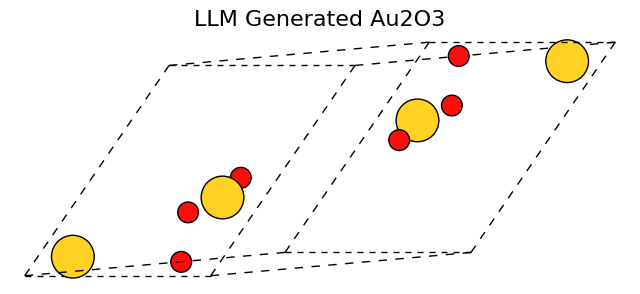

In [2]:
import io
import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize.plot import plot_atoms

# 1. Your generated CIF string
generated_cif = """data_Au2O3
_symmetry_space_group_name_H-M   'P 1'
_cell_length_a   5.02325740
_cell_length_b   5.02326070
_cell_length_c   5.07726109
_cell_angle_alpha   55.84310776
_cell_angle_beta   55.84306060
_cell_angle_gamma   55.84306911
_symmetry_Int_Tables_number   1
_chemical_formula_structural   Au2O3
_chemical_formula_sum   'Au4 O6'
_cell_volume   97.40508013
_cell_formula_units_Z   2
loop_
 _symmetry_equiv_pos_site_id
 _symmetry_equiv_pos_as_xyz
  1  'x, y, z'
loop_
 _atom_site_type_symbol
 _atom_site_label
 _atom_site_symmetry_multiplicity
 _atom_site_fract_x
 _atom_site_fract_y
 _atom_site_fract_z
 _atom_site_occupancy
  Au  Au0  1  0.33491232  0.33491232  0.33491232  1
  Au  Au1  1  0.66507762  0.66507762  0.66507762  1
  Au  Au2  1  0.91855742  0.91855742  0.91855742  1
  Au  Au3  1  0.08144258  0.08144258  0.08144258  1
  O  O4  1  0.53820139  0.96179381  0.74990432  1
  O  O5  1  0.25000432  0.53820139  0.96179381  1
  O  O6  1  0.96179381  0.74990432  0.53820139  1
  O  O7  1  0.03820139  0.25000432  0.46179381  1
  O  O8  1  0.46179381  0.03820371  0.24990432  1
  O  O9  1  0.74990432  0.46179861  0.03820139  1"""

# 2. Read the crystal
cif_file_object = io.StringIO(generated_cif)
ase_crystal = read(cif_file_object, format="cif")

# 3. Plot it statically using Matplotlib
fig, ax = plt.subplots(figsize=(8, 8))
# You can change the rotation tuple (x, y, z) to view from different angles!
plot_atoms(ase_crystal, ax, radii=0.3, rotation=('15x,45y,0z')) 
plt.axis('off')
plt.title("LLM Generated Au2O3", fontsize=16)
plt.show()

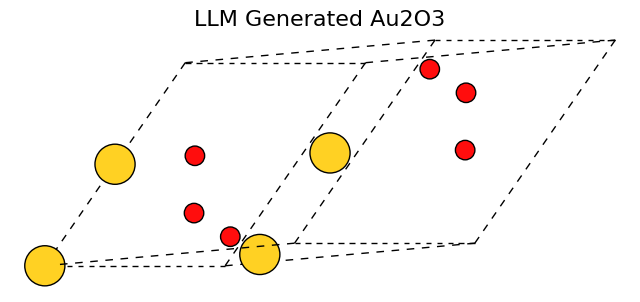

In [4]:
import io
import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize.plot import plot_atoms

# 1. Your generated CIF string
generated_cif = """data_Au2O3
_symmetry_space_group_name_H-M   'P 1'
_cell_length_a   5.18364737
_cell_length_b   5.18364894
_cell_length_c   5.18364944
_cell_angle_alpha   55.56325373
_cell_angle_beta   55.56324390
_cell_angle_gamma   55.56325385
_symmetry_Int_Tables_number   1
_chemical_formula_structural   Au2O3
_chemical_formula_sum   'Au4 O6'
_cell_volume   119.43582355
_cell_formula_units_Z   2
loop_
 _symmetry_equiv_pos_site_id
 _symmetry_equiv_pos_as_xyz
  1  'x, y, z'
loop_
 _atom_site_type_symbol
 _atom_site_label
 _atom_site_symmetry_multiplicity
 _atom_site_fract_x
 _atom_site_fract_y
 _atom_site_fract_z
 _atom_site_occupancy
  Au  Au0  1  0.50000000  -0.00000000  0.50000000  1
  Au  Au1  1  0.00000000  0.50000000  0.00000000  1
  Au  Au2  1  -0.00000000  0.00000000  0.00000000  1
  Au  Au3  1  0.50000000  0.50000000  0.50000000  1
  O  O4  1  0.25000000  0.08602174  0.51382174  1
  O  O5  1  0.51382174  0.25000000  0.08602174  1
  O  O6  1  0.08602174  0.51382174  0.25000000  1
  O  O7  1  0.75000000  0.91397826  0.48617826  1
  O  O8  1  0.48617826  0.75000000  0.91397826  1
  O  O9  1  0.91397826  0.48617826  0.75000000  1"""

# 2. Read the crystal
cif_file_object = io.StringIO(generated_cif)
ase_crystal = read(cif_file_object, format="cif")

# 3. Plot it statically using Matplotlib
fig, ax = plt.subplots(figsize=(8, 8))
# You can change the rotation tuple (x, y, z) to view from different angles!
plot_atoms(ase_crystal, ax, radii=0.3, rotation=('15x,45y,0z')) 
plt.axis('off')
plt.title("LLM Generated Au2O3", fontsize=16)
plt.show()

In [6]:
import io
import time
import sys
import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize.plot import plot_atoms

# 1. Force Python to see the 'src' folder on your cluster
BASE_DIR = "/nlsasfs/home/aikosh/prod-aikosh32/training_files"
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from src.mcts_decoder import CrystaLLMMCTS

# 2. Initialize the MCTS Engine (Maps to your A100 GPU)
print("Loading LLM and ALIGNN into A100 VRAM...")
engine = CrystaLLMMCTS(
    llm_path=f"{BASE_DIR}/data/models/crystallm-ar-final",
    tokenizer_path=f"{BASE_DIR}/data/tokenizer"
)

# 3. Setup the Au2O3 Prompt
prompt = "[CONTEXT]\n- The material Au2O3 is a stable crystal structure.\n- The formation energy is -2.0000 eV/atom.\n\n[TASK]\nBased on the context above, generate a valid CIF structure for:\nAu2O3\n\n[CIF START]\n"

# 4. Run the Generation Loop
print("\n🚀 Running 30 ALIGNN-Guided MCTS Simulations on A100...")
start_time = time.time()
best_cif, best_energy_label = engine.generate_guided(prompt, num_simulations=30)
end_time = time.time()

# 5. Inline Visualization (Bypasses Streamlit!)
if best_cif:
    print(f"\n✅ Generation Complete! ({round(end_time - start_time, 1)} seconds)")
    print(f"🏆 Best Energy: {best_energy_label}")
    print("Rendering Crystal Structure...")
    
    # Read the winning CIF string into ASE
    cif_file_object = io.StringIO(best_cif)
    ase_crystal = read(cif_file_object, format="cif")

    # Plot the 3D projection directly in Jupyter
    fig, ax = plt.subplots(figsize=(8, 8))
    plot_atoms(ase_crystal, ax, radii=0.3, rotation=('15x,45y,0z')) 
    plt.axis('off')
    plt.title(f"LLM Generated Au2O3\nEnergy: {best_energy_label}", fontsize=16)
    plt.show()
    
    # Save the raw text to a file for downloading to VESTA
    with open("final_generated_Au2O3.cif", "w") as f:
        f.write(best_cif)
    print("💾 Saved raw CIF file to 'final_generated_Au2O3.cif'")
    
else:
    print("\n❌ MCTS failed to find a physically stable topology. Try increasing num_simulations.")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading LLM and ALIGNN into A100 VRAM...
Loading LLM and Tokenizer...
Loading ALIGNN Formation Energy Predictor...
Using chk file jv_formation_energy_peratom_alignn/checkpoint_300.pt from  ['jv_formation_energy_peratom_alignn/checkpoint_300.pt']
Path /nlsasfs/home/aikosh/prod-aikosh32/.cache/atomgptlab/alignn_models/jv_formation_energy_peratom_alignn.zip
Config /nlsasfs/home/aikosh/prod-aikosh32/jv_formation_energy_peratom_alignn/config.json
config {'version': '9835fe0d4b313e2522034ff39f0ebdbfecde99a2', 'dataset': 'dft_3d', 'target': 'formation_energy_peratom', 'atom_features': 'cgcnn', 'neighbor_strategy': 'k-nearest', 'id_tag': 'jid', 'random_seed': 123, 'classification_threshold': None, 'n_val': None, 'n_test': None, 'n_train': None, 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1, 'target_multiplication_factor': None, 'epochs': 300, 'batch_size': 64, 'weight_decay': 1e-05, 'learning_rate': 0.001, 'filename': 'sample', 'warmup_steps': 2000, 'criterion': 'mse', 'optimizer': '

KeyboardInterrupt: 